# Loan Approval — Data Cleaning & Feature Engineering

Pipeline:
1. Drop `Loan_ID`
2. Encode `Loan_Status` (Y -> 1, N -> 0)
3. Normalize `Dependents` ("3+" -> 3)
4. Impute missing values (mode for categorical, median for numeric)
5. Engineer `TotalIncome`, `EMI`, `BalanceIncome`, log-transforms for skewed columns
6. One-hot encode the remaining categorical features
7. Save to `data/loan_cleaned.csv`

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append(".")
from utils import (load_data, drop_id, encode_target, normalize_dependents,
                   impute_missing, create_features, preprocess_data)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = load_data("data/loan.csv")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 2. Missing / Invalid Values

In [3]:
missing = df.isnull().sum()
print(missing[missing>0])
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64

Duplicate rows: 0


## 3. Drop ID, Encode Target, Normalize Dependents

In [4]:
df_no_id = drop_id(df)
df_enc   = encode_target(df_no_id)
df_dep   = normalize_dependents(df_enc)
print(f"After drops/encodes: {df_dep.shape}")
print(df_dep["Dependents"].value_counts())
df_dep.head()

After drops/encodes: (614, 12)
Dependents
0    360
1    102
2    101
3     51
Name: count, dtype: int64


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


## 4. Impute Missing Values

In [5]:
df_imp = impute_missing(df_dep)
print(f"Missing after imputation: {df_imp.isnull().sum().sum()}")
print()
print("Mode used for each imputed categorical column:")
for c in ["Gender","Married","Self_Employed","Credit_History"]:
    if c in df_dep.columns:
        print(f"  {c:18s}: {df_dep[c].mode().iloc[0]}")
print(f"\nMedian LoanAmount   : {df_dep['LoanAmount'].median():.1f}")
print(f"Median Loan_Amount_Term: {df_dep['Loan_Amount_Term'].median():.0f}")

Missing after imputation: 0

Mode used for each imputed categorical column:
  Gender            : Male
  Married           : Yes
  Self_Employed     : No
  Credit_History    : 1.0

Median LoanAmount   : 128.0
Median Loan_Amount_Term: 360


## 5. Distribution Comparison Before/After Imputation (LoanAmount)

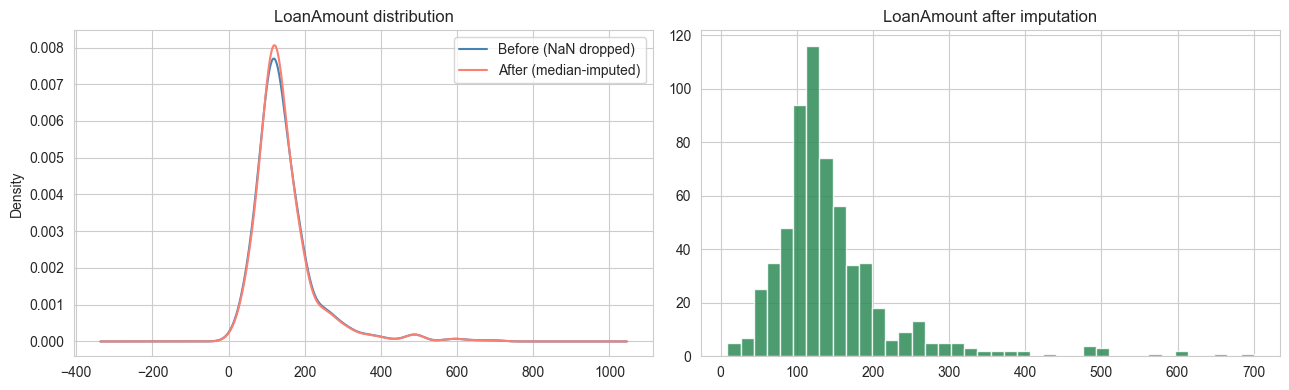

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_dep["LoanAmount"].dropna().plot(kind="kde", ax=axes[0], color="steelblue", label="Before (NaN dropped)")
df_imp["LoanAmount"].plot(kind="kde", ax=axes[0], color="salmon", label="After (median-imputed)")
axes[0].set_title("LoanAmount distribution"); axes[0].legend()

axes[1].hist(df_imp["LoanAmount"], bins=40, color="seagreen", edgecolor="white", alpha=0.85)
axes[1].set_title("LoanAmount after imputation")
plt.tight_layout(); plt.show()

## 6. Feature Engineering

In [7]:
df_feat = create_features(df_imp)
new_cols = [c for c in df_feat.columns if c not in df_imp.columns]
print(f"New features: {new_cols}")
df_feat[new_cols + ["Loan_Status"]].head()

New features: ['TotalIncome', 'EMI', 'BalanceIncome', 'LoanAmount_log', 'TotalIncome_log']


,TotalIncome,EMI,BalanceIncome,LoanAmount_log,TotalIncome_log,Loan_Status
0,5849.0,0.355556,5493.444444,4.859812,8.674197,1
1,6091.0,0.355556,5735.444444,4.859812,8.714732,0
2,3000.0,0.183333,2816.666667,4.204693,8.006701,1
3,4941.0,0.333333,4607.666667,4.795791,8.505525,1
4,6000.0,0.391667,5608.333333,4.955827,8.699681,1


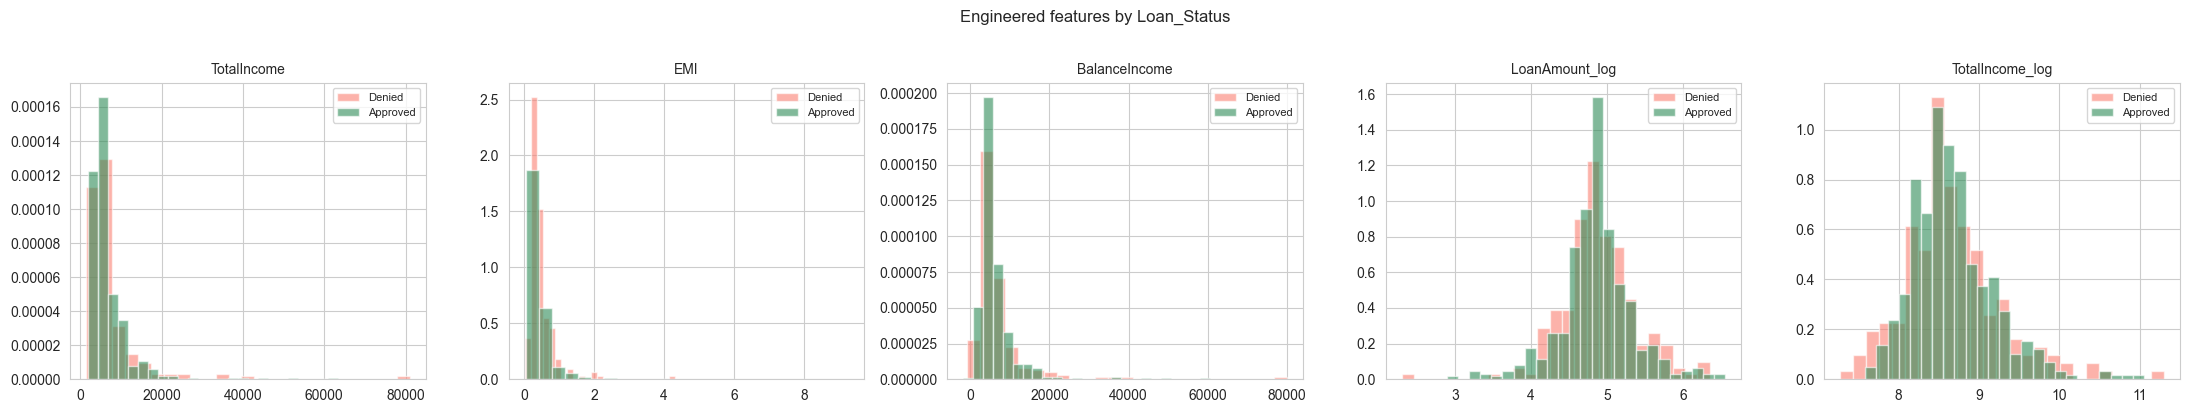

In [8]:
# Visualize new features by Loan_Status
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, col in enumerate(new_cols):
    for s, color, label in [(0, "salmon", "Denied"), (1, "seagreen", "Approved")]:
        sub = df_feat[df_feat["Loan_Status"] == s][col]
        axes[i].hist(sub, bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=10); axes[i].legend(fontsize=8)
plt.suptitle("Engineered features by Loan_Status", y=1.02)
plt.tight_layout(); plt.show()

## 7. Run the Full Pipeline

In [9]:
df_processed = preprocess_data(df)
print(f"Processed shape: {df_processed.shape}")
print(f"Missing values : {df_processed.isnull().sum().sum()}")
df_processed.head()

Processed shape: (614, 18)
Missing values : 0


,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,EMI,BalanceIncome,LoanAmount_log,TotalIncome_log,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5849,0.0,128.0,360.0,1.0,1,5849.0,0.355556,5493.444444,4.859812,8.674197,1,0,0,0,0,1
1,1,4583,1508.0,128.0,360.0,1.0,0,6091.0,0.355556,5735.444444,4.859812,8.714732,1,1,0,0,0,0
2,0,3000,0.0,66.0,360.0,1.0,1,3000.0,0.183333,2816.666667,4.204693,8.006701,1,1,0,1,0,1
3,0,2583,2358.0,120.0,360.0,1.0,1,4941.0,0.333333,4607.666667,4.795791,8.505525,1,1,1,0,0,1
4,0,6000,0.0,141.0,360.0,1.0,1,6000.0,0.391667,5608.333333,4.955827,8.699681,1,0,0,0,0,1


## 8. Sanity Checks & Save

In [10]:
assert df_processed["Loan_Status"].isin([0, 1]).all()
assert df_processed.isnull().sum().sum() == 0
assert "Loan_ID" not in df_processed.columns
print("All checks passed.")

All checks passed.


In [11]:
df_processed.to_csv("data/loan_cleaned.csv", index=False)
print(f"Saved data/loan_cleaned.csv ({df_processed.shape[0]} rows, {df_processed.shape[1]} cols)")

Saved data/loan_cleaned.csv (614 rows, 18 cols)
